<a href="https://colab.research.google.com/github/nileve-teo/Metodos-numericos/blob/main/met_6_04_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📌 ÍNDICE GENERAL DE ALGORITMOS *(colab)*

Selecciona el método que deseas ejecutar para ir directamente a su sección:

1. 📈 [Métoso de  Newton (Con redondeo a 6 decimales)](#scrollTo=YIlM_NnRSv6m)
   * 1.a. 📈 [Sin redondeo](#scrollTo=YIlM_NnRSv6m)
2. 📊 [Método de Lagrange](#scrollTo=Oz38t-ysT7sT)
3. 📁 [Entrada (Solo genera Newton - Pide CSV de Google Sheets)](#scrollTo=LA96BdH1VVnk)
   * 3.1. 📊 [Evalúa Newton, Lagrange y Redondeados (Pide iframe de Sheets)](#scrollTo=ctCEsktNbXnD)
   * 3.2. 📊 [Genera Newton y Lagrange (Pide link de Sheets - Opción B)](#scrollTo=m8bKnxkDb9TT)
   * 3.3. 📊 [Genera Newton y Lagrange (Pide iframe de Sheets - Opción C)](#scrollTo=gnNfo1PrcVOb)
   * 3.4. 📊 [Genera Newton y Lagrange (Opciones: Sheets o archivo Excel)](#scrollTo=FRiyHSbPc1eb)
4. ⚡ [Optimizado](#scrollTo=xU8IDW6ken1E)
    * 4.1. 📊 [Genera Newton y gráfica de Lagrange (Opciones: Sheets o archivo Excel)](#scrollTo=LBKqpn_385XM)

---


<h1>📌 ÍNDICE GENERAL DE ALGORITMOS</h1>

<ul>
  <li><a href="#newton">📈 Método de Newton</a></li>
  <li><a href="#newton_sin_redondeo">📈 Newton sin redondeo</a></li>
  <li><a href="#lagrange">📊 Método de Lagrange</a></li>
  <li><a href="#entrada">📁 Entrada</a></li>
  <li><a href="#entrada1">📊 Evalúa Newton y Lagrange</a></li>
  <li><a href="#entrada2">📊 Genera Newton y Lagrange (Opción B)</a></li>
  <li><a href="#entrada3">📊 Genera Newton y Lagrange (Opción C)</a></li>
  <li><a href="#entrada4">📊 Sheets o Excel</a></li>
  <li><a href="#optimizado">⚡ Optimizado</a></li>
  <li><a href="#optimizado1">📊 Newton y gráfica de Lagrange</a></li>
</ul>

<a id="newton"></a>

# Método de Newton

Con redondeo a 6 decimales (:.6f)

Interpolación en x = 3.5 → f(3.5) ≈ 11.125000


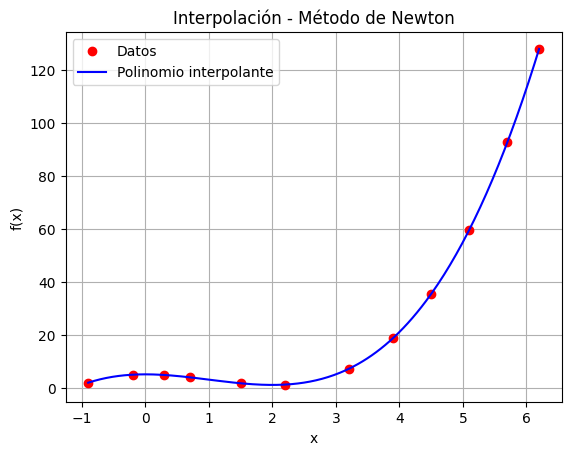

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Datos
x = np.array([-0.9, -0.2, 0.3, 0.7, 1.5, 2.2, 3.2, 3.9, 4.5, 5.1, 5.7, 6.2])
y = np.array([1.841, 4.872, 4.757, 3.873, 1.625, 1.128, 7.048, 18.689, 35.375, 59.621, 92.723, 128.008])

n = len(x)

# =========================
# MÉTODO DE NEWTON
# =========================
D = np.zeros((n,n))
D[:,0] = y

for j in range(1,n):
    for i in range(n-j):
        D[i,j] = (D[i+1,j-1] - D[i,j-1]) / (x[i+j] - x[i])

# Evaluación en x = 3.5
xp = 3.5
p = D[0,0]
prod = 1

for i in range(1,n):
    prod *= (xp - x[i-1])
    p += D[0,i]*prod

print(f"Interpolación en x = 3.5 → f(3.5) ≈ {p:.6f}")

# =========================
# GRAFICAR
# =========================
xx = np.linspace(min(x), max(x), 300)
yy = np.zeros_like(xx)

for k in range(len(xx)):
    prod = 1
    yy[k] = D[0,0]
    for i in range(1,n):
        prod *= (xx[k] - x[i-1])
        yy[k] += D[0,i]*prod

plt.plot(x, y, 'ro', label='Datos')
plt.plot(xx, yy, 'b-', label='Polinomio interpolante')
plt.grid()
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Interpolación - Método de Newton')
plt.legend()
plt.show()

<a id="newton_sin_redondeo"></a>

Resultado en punto flotante (sin redondeo)


Polinomio de Newton (inicio):

5.26949258159129e-18*x**11 - 1.45747518975209e-16*x**10 + 1.67691191644846e-15*x**9 - 1.03353250945469e-14*x**8 + 3.63519943763313e-14*x**7 - 7.01919167106649e-14*x**6 + 5.69652723656297e-14*x**5 + 2.38664181836925e-14*x**4 + 0.999999999999928*x**3 - 2.99999999999997*x**2 - 3.87685002403883e-16*x + 5.0 ...

✔ Polinomio completo guardado en 'polinomio_newton.txt'

f(3.5) = 11.124999999999993


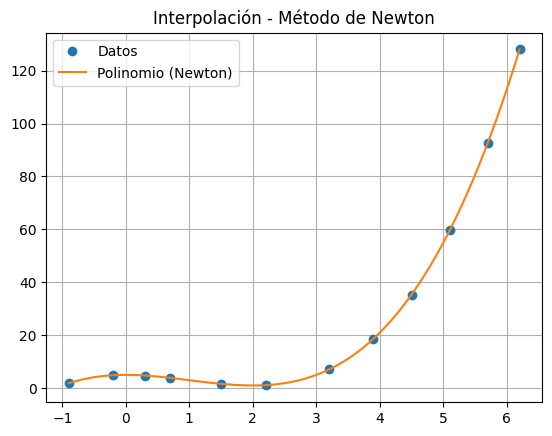

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# =========================
# DATOS
# =========================
x_vals = [-0.9, -0.2, 0.3, 0.7, 1.5, 2.2, 3.2, 3.9, 4.5, 5.1, 5.7, 6.2]
y_vals = [1.841, 4.872, 4.757, 3.873, 1.625, 1.128, 7.048, 18.689, 35.375, 59.621, 92.723, 128.008]

n = len(x_vals)

# =========================
# DIFERENCIAS DIVIDIDAS
# =========================
D = np.zeros((n, n))
D[:,0] = y_vals

for j in range(1, n):
    for i in range(n - j):
        D[i,j] = (D[i+1,j-1] - D[i,j-1]) / (x_vals[i+j] - x_vals[i])

# =========================
# POLINOMIO SIMBÓLICO
# =========================
x = sp.symbols('x')
P = D[0,0]

prod = 1
for i in range(1, n):
    prod *= (x - x_vals[i-1])
    P += D[0,i] * prod

# Expandir
P_expandido = sp.expand(P)

# Mostrar parte del polinomio
print("\nPolinomio de Newton (inicio):\n")
print(str(P_expandido)[:500], "...")

# Guardar completo en archivo
with open("polinomio_newton.txt", "w") as f:
    f.write(str(P_expandido))

print("\n✔ Polinomio completo guardado en 'polinomio_newton.txt'")

# =========================
# EVALUACIÓN
# =========================
xp = 3.5
valor = P_expandido.subs(x, xp)
print("\nf(3.5) =", float(valor))

# =========================
# FUNCIÓN NUMÉRICA (NEWTON)
# =========================
def newton_eval(xp):
    resultado = D[0,0]
    prod = 1
    for i in range(1, n):
        prod *= (xp - x_vals[i-1])
        resultado += D[0,i]*prod
    return resultado

# =========================
# GRÁFICA
# =========================
xx = np.linspace(min(x_vals), max(x_vals), 300)
yy = [newton_eval(xi) for xi in xx]

plt.figure()
plt.plot(x_vals, y_vals, 'o', label='Datos')
plt.plot(xx, yy, label='Polinomio (Newton)')
plt.grid()
plt.legend()
plt.title("Interpolación - Método de Newton")

# Guardar imagen
plt.savefig("grafica_newton.png")

# Mostrar
plt.show()

<a id="lagrange"></a>

# 📊 Método de Lagrange


*Polinomio*  (expandido)


Polinomio (primeros términos):

3.46944695195361e-18*x**11 - 2.22044604925031e-16*x**10 + 1.77635683940025e-15*x**9 - 2.1316282072803e-14*x**8 + 7.8159700933611e-14*x**7 - 9.9475983006414e-14*x**6 + 8.5265128291212e-14*x**5 + 2.8421709430404e-14*x**4 + 0.999999999999957*x**3 - 2.99999999999998*x**2 + 1.82076576038526e-14*x + 5.0 ...

✔ Polinomio guardado en 'polinomio_lagrange.txt'

f(3.5) = 11.124999999999996


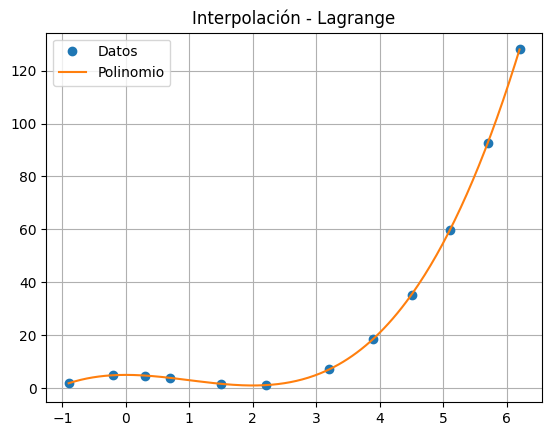

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

# =========================
# DATOS
# =========================
x_vals = [-0.9, -0.2, 0.3, 0.7, 1.5, 2.2, 3.2, 3.9, 4.5, 5.1, 5.7, 6.2]
y_vals = [1.841, 4.872, 4.757, 3.873, 1.625, 1.128, 7.048, 18.689, 35.375, 59.621, 92.723, 128.008]

# =========================
# POLINOMIO SIMBÓLICO (LAGRANGE)
# =========================
x = sp.symbols('x')
P = 0
n = len(x_vals)

for i in range(n):
    Li = 1
    for j in range(n):
        if i != j:
            Li *= (x - x_vals[j])/(x_vals[i] - x_vals[j])
    P += y_vals[i]*Li

P_expandido = sp.expand(P)

# 🔹 Mostrar solo una parte (porque es enorme)
print("\nPolinomio (primeros términos):\n")
print(str(P_expandido)[:500], "...")

# =========================
# GUARDAR POLINOMIO COMO TEXTO (MEJOR OPCIÓN)
# =========================
with open("polinomio_lagrange.txt", "w") as f:
    f.write(str(P_expandido))

print("\n✔ Polinomio guardado en 'polinomio_lagrange.txt'")

# =========================
# FUNCIÓN NUMÉRICA
# =========================
def lagrange(xp):
    total = 0
    for i in range(n):
        Li = 1
        for j in range(n):
            if i != j:
                Li *= (xp - x_vals[j])/(x_vals[i] - x_vals[j])
        total += y_vals[i] * Li
    return total

# =========================
# EVALUACIÓN
# =========================
xp = 3.5
print("\nf(3.5) =", lagrange(xp))

# =========================
# GRÁFICA
# =========================
xx = np.linspace(min(x_vals), max(x_vals), 300)
yy = [lagrange(xi) for xi in xx]

plt.figure()
plt.plot(x_vals, y_vals, 'o', label='Datos')
plt.plot(xx, yy, label='Polinomio')
plt.grid()
plt.legend()
plt.title("Interpolación - Lagrange")

# Guardar imagen
plt.savefig("grafica_lagrange.png")

# Mostrar
plt.show()

<a id="entrada"></a>

# 📁 Entrada


*   excel
*   punto de evaluacion



Pega el link CSV de Google Sheets: https://docs.google.com/spreadsheets/d/e/2PACX-1vQMk2rONqEyeyA1t0XZzBRJj-OKDDxgGmaEcD7VDXZsfz5tnmwwRuwAgYU7DGACkw/pub?output=csv

Datos cargados:
       x     f(x)
0   -0,9    1,841
1   -0,2    4,872
2    0,3    4,757
3    0,7    3,873
4    1,5    1,625
5    2,2    1,128
6    3,2    7,048
7    3,9   18,689
8    4,5   35,375
9    5,1   59,621
10   5,7   92,723
11   6,2  128,008

Ingrese el valor de x a evaluar: 3.5

Resultado: 11.124999999999995
Redondeado: 11.125000


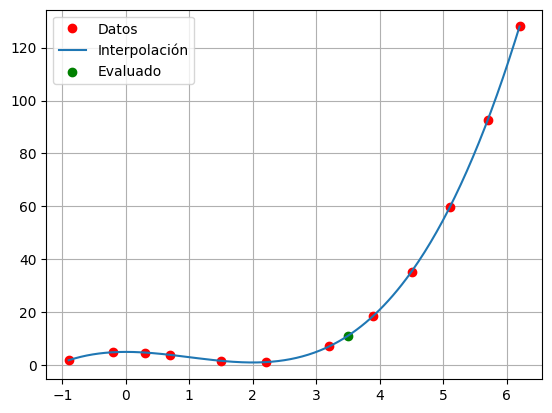

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# =========================
# LEER DESDE GOOGLE SHEETS
# =========================
url = input("Pega el link CSV de Google Sheets: ")

data = pd.read_csv(url)

# Extraer columnas
x = data.iloc[:,0].values
y = data.iloc[:,1].values

n = len(x)

print("\nDatos cargados:")
print(data)

# Convertir comas a punto decimal
data.iloc[:,0] = data.iloc[:,0].astype(str).str.replace(',', '.')
data.iloc[:,1] = data.iloc[:,1].astype(str).str.replace(',', '.')

# Convertir a float
x = data.iloc[:,0].astype(float).values
y = data.iloc[:,1].astype(float).values

# =========================
# PEDIR PUNTO
# =========================
xp = float(input("\nIngrese el valor de x a evaluar: "))

# =========================
# NEWTON
# =========================
D = np.zeros((n,n))
D[:,0] = y

for j in range(1,n):
    for i in range(n-j):
        D[i,j] = (D[i+1,j-1] - D[i,j-1]) / (x[i+j] - x[i])

p = D[0,0]
prod = 1

for i in range(1,n):
    prod *= (xp - x[i-1])
    p += D[0,i]*prod

print(f"\nResultado: {p}")
print(f"Redondeado: {p:.6f}")

# =========================
# GRÁFICA
# =========================
def newton_eval(xp):
    res = D[0,0]
    prod = 1
    for i in range(1,n):
        prod *= (xp - x[i-1])
        res += D[0,i]*prod
    return res

xx = np.linspace(min(x), max(x), 300)
yy = [newton_eval(xi) for xi in xx]

plt.plot(x, y, 'ro', label='Datos')
plt.plot(xx, yy, label='Interpolación')
plt.scatter(xp, p, color='green', label='Evaluado')
plt.legend()
plt.grid()
plt.show()





<a id="entrada1"></a>

## 3.1 Evalúa Newton, Lagrange y Redondeados

Pega el link de Google Sheets: <iframe src="https://docs.google.com/spreadsheets/d/e/2PACX-1vQMk2rONqEyeyA1t0XZzBRJj-OKDDxgGmaEcD7VDXZsfz5tnmwwRuwAgYU7DGACkw/pubhtml?widget=true&amp;headers=false"></iframe>

Link corregido: https://docs.google.com/spreadsheets/d/e/2PACX-1vQMk2rONqEyeyA1t0XZzBRJj-OKDDxgGmaEcD7VDXZsfz5tnmwwRuwAgYU7DGACkw/pub?output=csv

Datos cargados:
       x     f(x)
0   -0,9    1,841
1   -0,2    4,872
2    0,3    4,757
3    0,7    3,873
4    1,5    1,625
5    2,2    1,128
6    3,2    7,048
7    3,9   18,689
8    4,5   35,375
9    5,1   59,621
10   5,7   92,723
11   6,2  128,008

Ingrese el valor de x a evaluar: 3.5

=== RESULTADOS ===
Newton: 11.124999999999995
Lagrange: 11.124999999999996
Redondeado Newton: 11.125000
Redondeado Lagrange: 11.125000


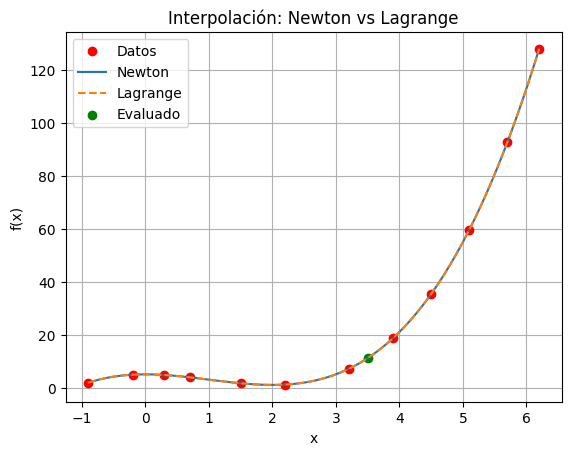

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

# =========================
# LEER LINK (AUTOMÁTICO)
# =========================
url = input("Pega el link de Google Sheets: ")

# Limpiar iframe si existe
if "<iframe" in url:
    url = re.search(r'src="([^"]+)"', url).group(1)

# Convertir a CSV
if "pubhtml" in url:
    url = url.split("?")[0]
    url = url.replace("pubhtml", "pub") + "?output=csv"

if "pub" in url and "output=csv" not in url:
    url = url.split("?")[0] + "?output=csv"

print("\nLink corregido:", url)

# Leer datos
data = pd.read_csv(url)

print("\nDatos cargados:")
print(data)

# =========================
# LIMPIEZA DE DATOS (coma decimal)
# =========================
data.iloc[:,0] = data.iloc[:,0].astype(str).str.replace(',', '.')
data.iloc[:,1] = data.iloc[:,1].astype(str).str.replace(',', '.')

x = data.iloc[:,0].astype(float).values
y = data.iloc[:,1].astype(float).values

n = len(x)

# =========================
# PEDIR PUNTO
# =========================
xp = float(input("\nIngrese el valor de x a evaluar: "))

# =========================
# NEWTON
# =========================
D = np.zeros((n,n))
D[:,0] = y

for j in range(1,n):
    for i in range(n-j):
        D[i,j] = (D[i+1,j-1] - D[i,j-1]) / (x[i+j] - x[i])

p_newton = D[0,0]
prod = 1

for i in range(1,n):
    prod *= (xp - x[i-1])
    p_newton += D[0,i]*prod

# =========================
# LAGRANGE
# =========================
def lagrange(x, y, xp):
    n = len(x)
    resultado = 0
    for i in range(n):
        Li = 1
        for j in range(n):
            if i != j:
                Li *= (xp - x[j])/(x[i] - x[j])
        resultado += y[i]*Li
    return resultado

p_lagrange = lagrange(x, y, xp)

# =========================
# RESULTADOS
# =========================
print("\n=== RESULTADOS ===")
print(f"Newton: {p_newton}")
print(f"Lagrange: {p_lagrange}")
print(f"Redondeado Newton: {p_newton:.6f}")
print(f"Redondeado Lagrange: {p_lagrange:.6f}")

# =========================
# FUNCIONES PARA GRAFICAR
# =========================
def newton_eval(xp):
    res = D[0,0]
    prod = 1
    for i in range(1,n):
        prod *= (xp - x[i-1])
        res += D[0,i]*prod
    return res

# =========================
# GRÁFICA
# =========================
xx = np.linspace(min(x), max(x), 300)
yy_newton = [newton_eval(xi) for xi in xx]
yy_lagrange = [lagrange(x, y, xi) for xi in xx]

plt.figure()
plt.plot(x, y, 'ro', label='Datos')
plt.plot(xx, yy_newton, label='Newton')
plt.plot(xx, yy_lagrange, '--', label='Lagrange')
plt.scatter(xp, p_newton, color='green', label='Evaluado')

plt.title("Interpolación: Newton vs Lagrange")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()

plt.show()

<a id="entrada2"></a>

## 3.2 Genera Newton y Lagrange (Opción B)

Pega el link de Google Sheets: https://docs.google.com/spreadsheets/d/e/2PACX-1vSq7FbGnnGtkyyAAlKFn7YwEYGLL1RaUXdGlKggsJfTLg2H3fIaHwBStFIWanejxd46_p_UY2c6EPj5/pubhtml?gid=1964087744&single=true

Link corregido: https://docs.google.com/spreadsheets/d/e/2PACX-1vSq7FbGnnGtkyyAAlKFn7YwEYGLL1RaUXdGlKggsJfTLg2H3fIaHwBStFIWanejxd46_p_UY2c6EPj5/pub?output=csv

Datos cargados:
     x    f(x)
0 -1.0  38.461
1 -0.6   0.100
2 -0.2   0.500
3  0.2   0.500
4  0.6   0.100
5  1.0  38.461

Ingrese el valor de x a evaluar: 0.32

=== RESULTADOS ===
Newton:     -0.602550
Lagrange:   -0.602550


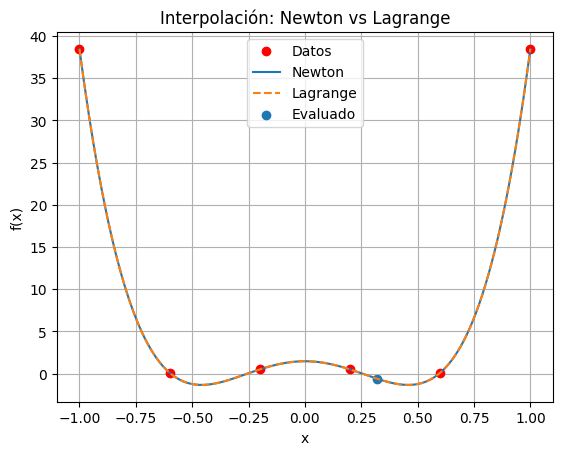

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

# =========================
# FUNCIÓN: LIMPIAR LINK
# =========================
def limpiar_link(url):
    if "<iframe" in url:
        url = re.search(r'src="([^"]+)"', url).group(1)

    if "pubhtml" in url:
        url = url.split("?")[0]
        url = url.replace("pubhtml", "pub") + "?output=csv"

    elif "pub" in url and "output=csv" not in url:
        url = url.split("?")[0] + "?output=csv"

    return url


# =========================
# FUNCIÓN: LIMPIAR DATOS
# =========================
def limpiar_datos(data):
    x = data.iloc[:, 0].astype(str).str.replace(',', '.').astype(float).values
    y = data.iloc[:, 1].astype(str).str.replace(',', '.').astype(float).values
    return x, y


# =========================
# FUNCIÓN: NEWTON
# =========================
def newton_interpolacion(x, y, xp):
    n = len(x)
    D = np.zeros((n, n))
    D[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            D[i, j] = (D[i+1, j-1] - D[i, j-1]) / (x[i+j] - x[i])

    resultado = D[0, 0]
    producto = 1

    for i in range(1, n):
        producto *= (xp - x[i-1])
        resultado += D[0, i] * producto

    return resultado, D


# =========================
# FUNCIÓN: LAGRANGE
# =========================
def lagrange_interpolacion(x, y, xp):
    n = len(x)
    resultado = 0

    for i in range(n):
        Li = 1
        for j in range(n):
            if i != j:
                Li *= (xp - x[j]) / (x[i] - x[j])
        resultado += y[i] * Li

    return resultado


# =========================
# PROGRAMA PRINCIPAL
# =========================
url = input("Pega el link de Google Sheets: ")
url = limpiar_link(url)

print("\nLink corregido:", url)

# Leer datos
data = pd.read_csv(url)

print("\nDatos cargados:")
print(data)

# Limpiar datos
x, y = limpiar_datos(data)

# Punto a evaluar
xp = float(input("\nIngrese el valor de x a evaluar: "))

# Cálculos
resultado_newton, tabla_D = newton_interpolacion(x, y, xp)
resultado_lagrange = lagrange_interpolacion(x, y, xp)

# =========================
# RESULTADOS
# =========================
print("\n=== RESULTADOS ===")
print(f"Newton:     {resultado_newton:.6f}")
print(f"Lagrange:   {resultado_lagrange:.6f}")

# =========================
# GRAFICACIÓN
# =========================
def evaluar_newton(xp, x, D):
    n = len(x)
    res = D[0, 0]
    prod = 1
    for i in range(1, n):
        prod *= (xp - x[i-1])
        res += D[0, i] * prod
    return res

xx = np.linspace(min(x), max(x), 300)
yy_newton = [evaluar_newton(xi, x, tabla_D) for xi in xx]
yy_lagrange = [lagrange_interpolacion(x, y, xi) for xi in xx]

plt.figure()
plt.plot(x, y, 'ro', label='Datos')
plt.plot(xx, yy_newton, label='Newton')
plt.plot(xx, yy_lagrange, '--', label='Lagrange')
plt.scatter(xp, resultado_newton, label='Evaluado')

plt.title("Interpolación: Newton vs Lagrange")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()

plt.show()

<a id="entrada3"></a>

## 3.3 Genera Newton y Lagrange (Opción C)

Pega el link de Google Sheets: <iframe src="https://docs.google.com/spreadsheets/d/e/2PACX-1vQMk2rONqEyeyA1t0XZzBRJj-OKDDxgGmaEcD7VDXZsfz5tnmwwRuwAgYU7DGACkw/pubhtml?widget=true&amp;headers=false"></iframe>

Link corregido: https://docs.google.com/spreadsheets/d/e/2PACX-1vQMk2rONqEyeyA1t0XZzBRJj-OKDDxgGmaEcD7VDXZsfz5tnmwwRuwAgYU7DGACkw/pub?output=csv

Datos cargados:
       x     f(x)
0   -0,9    1,841
1   -0,2    4,872
2    0,3    4,757
3    0,7    3,873
4    1,5    1,625
5    2,2    1,128
6    3,2    7,048
7    3,9   18,689
8    4,5   35,375
9    5,1   59,621
10   5,7   92,723
11   6,2  128,008

Ingrese el valor de x a evaluar: 3.5

=== RESULTADOS ===
Newton:     11.125000
Lagrange:   11.125000


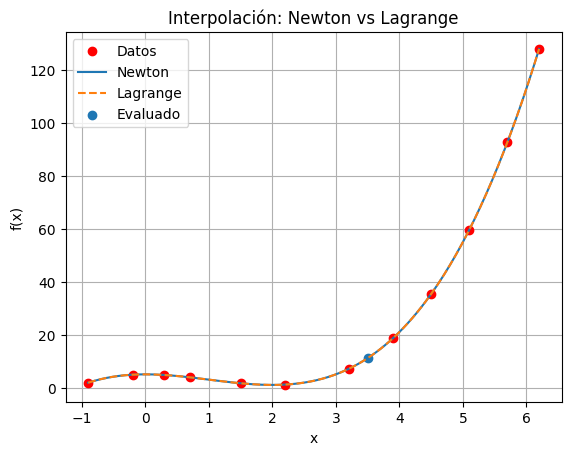

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re

# =========================
# FUNCIÓN: LIMPIAR LINK
# =========================
def limpiar_link(url):
    if "<iframe" in url:
        url = re.search(r'src="([^"]+)"', url).group(1)

    if "pubhtml" in url:
        url = url.split("?")[0]
        url = url.replace("pubhtml", "pub") + "?output=csv"

    elif "pub" in url and "output=csv" not in url:
        url = url.split("?")[0] + "?output=csv"

    return url


# =========================
# FUNCIÓN: LIMPIAR DATOS
# =========================
def limpiar_datos(data):
    x = data.iloc[:, 0].astype(str).str.replace(',', '.').astype(float).values
    y = data.iloc[:, 1].astype(str).str.replace(',', '.').astype(float).values
    return x, y


# =========================
# FUNCIÓN: NEWTON
# =========================
def newton_interpolacion(x, y, xp):
    n = len(x)
    D = np.zeros((n, n))
    D[:, 0] = y

    for j in range(1, n):
        for i in range(n - j):
            D[i, j] = (D[i+1, j-1] - D[i, j-1]) / (x[i+j] - x[i])

    resultado = D[0, 0]
    producto = 1

    for i in range(1, n):
        producto *= (xp - x[i-1])
        resultado += D[0, i] * producto

    return resultado, D


# =========================
# FUNCIÓN: LAGRANGE
# =========================
def lagrange_interpolacion(x, y, xp):
    n = len(x)
    resultado = 0

    for i in range(n):
        Li = 1
        for j in range(n):
            if i != j:
                Li *= (xp - x[j]) / (x[i] - x[j])
        resultado += y[i] * Li

    return resultado


# =========================
# PROGRAMA PRINCIPAL
# =========================
url = input("Pega el link de Google Sheets: ")
url = limpiar_link(url)

print("\nLink corregido:", url)

# Leer datos
data = pd.read_csv(url)

print("\nDatos cargados:")
print(data)

# Limpiar datos
x, y = limpiar_datos(data)

# Punto a evaluar
xp = float(input("\nIngrese el valor de x a evaluar: "))

# Cálculos
resultado_newton, tabla_D = newton_interpolacion(x, y, xp)
resultado_lagrange = lagrange_interpolacion(x, y, xp)

# =========================
# RESULTADOS
# =========================
print("\n=== RESULTADOS ===")
print(f"Newton:     {resultado_newton:.6f}")
print(f"Lagrange:   {resultado_lagrange:.6f}")

# =========================
# GRAFICACIÓN
# =========================
def evaluar_newton(xp, x, D):
    n = len(x)
    res = D[0, 0]
    prod = 1
    for i in range(1, n):
        prod *= (xp - x[i-1])
        res += D[0, i] * prod
    return res

xx = np.linspace(min(x), max(x), 300)
yy_newton = [evaluar_newton(xi, x, tabla_D) for xi in xx]
yy_lagrange = [lagrange_interpolacion(x, y, xi) for xi in xx]

plt.figure()
plt.plot(x, y, 'ro', label='Datos')
plt.plot(xx, yy_newton, label='Newton')
plt.plot(xx, yy_lagrange, '--', label='Lagrange')
plt.scatter(xp, resultado_newton, label='Evaluado')

plt.title("Interpolación: Newton vs Lagrange")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()

plt.show()

<a id="entrada4"></a>

## 3.4 Sheets o Excel

¿Usar (1) Google Sheets o (2) archivo Excel? 2
Sube tu archivo Excel (.xlsx):


Saving Prueba_semana2.xlsx to Prueba_semana2.xlsx

Datos cargados:
     x     f(x)
0 -1.0  38461.0
1 -0.6      0.1
2 -0.2      0.5
3  0.2      0.5
4  0.6      0.1
5  1.0  38461.0

Ingrese el valor de x a evaluar: 0.32

=== RESULTADOS ===
Newton:   -1005.832226
Lagrange: -1005.832226


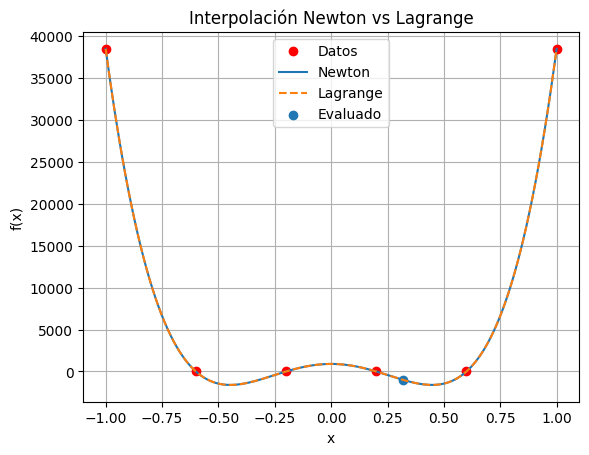

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from google.colab import files

# =========================
# FUNCIÓN: LIMPIAR LINK
# =========================
def limpiar_link(url):
    if "<iframe" in url:
        url = re.search(r'src="([^"]+)"', url).group(1)

    if "pubhtml" in url:
        url = url.split("?")[0]
        url = url.replace("pubhtml", "pub") + "?output=csv"

    elif "pub" in url and "output=csv" not in url:
        url = url.split("?")[0] + "?output=csv"

    return url


# =========================
# FUNCIÓN: LIMPIAR DATOS
# =========================
def limpiar_datos(data):
    x = data.iloc[:, 0].astype(str).str.replace(',', '.').astype(float).values
    y = data.iloc[:, 1].astype(str).str.replace(',', '.').astype(float).values
    return x, y


# =========================
# ELEGIR MODO
# =========================
modo = input("¿Usar (1) Google Sheets o (2) archivo Excel? ")

if modo == "1":
    url = input("Pega el link de Google Sheets: ")
    url = limpiar_link(url)
    print("\nLink corregido:", url)
    data = pd.read_csv(url)

elif modo == "2":
    print("Sube tu archivo Excel (.xlsx):")
    uploaded = files.upload()
    archivo = list(uploaded.keys())[0]
    data = pd.read_excel(archivo)

else:
    print("Opción no válida")
    exit()

print("\nDatos cargados:")
print(data)

# =========================
# LIMPIAR DATOS
# =========================
x, y = limpiar_datos(data)
n = len(x)

# =========================
# PUNTO A EVALUAR
# =========================
xp = float(input("\nIngrese el valor de x a evaluar: "))

# =========================
# NEWTON
# =========================
D = np.zeros((n, n))
D[:, 0] = y

for j in range(1, n):
    for i in range(n - j):
        D[i, j] = (D[i+1, j-1] - D[i, j-1]) / (x[i+j] - x[i])

p_newton = D[0, 0]
prod = 1

for i in range(1, n):
    prod *= (xp - x[i-1])
    p_newton += D[0, i] * prod

# =========================
# LAGRANGE
# =========================
def lagrange(x, y, xp):
    n = len(x)
    resultado = 0
    for i in range(n):
        Li = 1
        for j in range(n):
            if i != j:
                Li *= (xp - x[j])/(x[i] - x[j])
        resultado += y[i]*Li
    return resultado

p_lagrange = lagrange(x, y, xp)

# =========================
# RESULTADOS
# =========================
print("\n=== RESULTADOS ===")
print(f"Newton:   {p_newton:.6f}")
print(f"Lagrange: {p_lagrange:.6f}")

# =========================
# GRÁFICA
# =========================
def newton_eval(xp):
    res = D[0, 0]
    prod = 1
    for i in range(1, n):
        prod *= (xp - x[i-1])
        res += D[0, i] * prod
    return res

xx = np.linspace(min(x), max(x), 300)
yy_newton = [newton_eval(xi) for xi in xx]
yy_lagrange = [lagrange(x, y, xi) for xi in xx]

plt.plot(x, y, 'ro', label='Datos')
plt.plot(xx, yy_newton, label='Newton')
plt.plot(xx, yy_lagrange, '--', label='Lagrange')
plt.scatter(xp, p_newton, label='Evaluado')

plt.title("Interpolación Newton vs Lagrange")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()

plt.show()

<a id="optimizado"></a>

# ⚡ Optimizado

¿Usar (1) Google Sheets o (2) archivo Excel? 2
Sube tu archivo Excel (.xlsx):


Saving Prueba_semana2 (1).xlsx to Prueba_semana2 (1) (1).xlsx

Datos cargados:
     x      f(x)
0 -1.0  0.038461
1 -0.6  0.100000
2 -0.2  0.500000
3  0.2  0.500000
4  0.6  0.100000
5  1.0  0.038461

Ingrese el valor de x a evaluar: 0.32

=== RESULTADOS ===

--- Valores completos ---
Newton:    0.40268001408749987
Lagrange:  0.4026800140874999

--- Redondeado (10 decimales) ---
Newton:   0.4026800141
Lagrange: 0.4026800141

--- Diferencia absoluta ---
5.551115123125783e-17


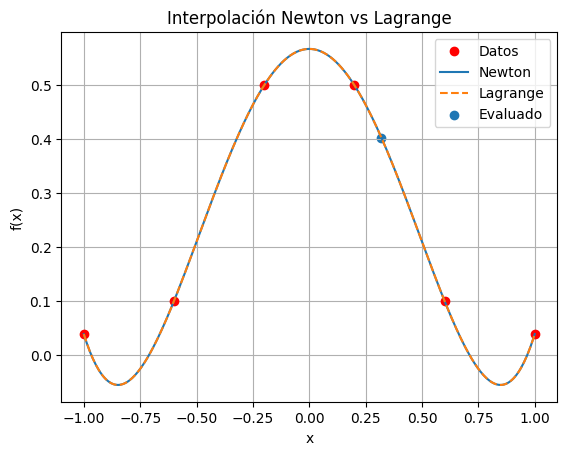

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from google.colab import files

# =========================
# FUNCIÓN: LIMPIAR LINK
# =========================
def limpiar_link(url):
    if "<iframe" in url:
        url = re.search(r'src="([^"]+)"', url).group(1)

    if "pubhtml" in url:
        url = url.split("?")[0]
        url = url.replace("pubhtml", "pub") + "?output=csv"

    elif "pub" in url and "output=csv" not in url:
        url = url.split("?")[0] + "?output=csv"

    return url


# =========================
# FUNCIÓN: LIMPIAR DATOS
# =========================
def limpiar_datos(data):
    x = data.iloc[:, 0].astype(str).str.replace(',', '.').astype(float).values
    y = data.iloc[:, 1].astype(str).str.replace(',', '.').astype(float).values
    return x, y


# =========================
# ELEGIR MODO
# =========================
modo = input("¿Usar (1) Google Sheets o (2) archivo Excel? ")

if modo == "1":
    url = input("Pega el link de Google Sheets: ")
    url = limpiar_link(url)
    print("\nLink corregido:", url)
    data = pd.read_csv(url)

elif modo == "2":
    print("Sube tu archivo Excel (.xlsx):")
    uploaded = files.upload()
    archivo = list(uploaded.keys())[0]
    data = pd.read_excel(archivo)

else:
    print("Opción no válida")
    exit()

print("\nDatos cargados:")
print(data)

# =========================
# LIMPIAR DATOS
# =========================
x, y = limpiar_datos(data)
n = len(x)

# =========================
# PUNTO A EVALUAR
# =========================
xp = float(input("\nIngrese el valor de x a evaluar: "))

# =========================
# NEWTON
# =========================
D = np.zeros((n, n))
D[:, 0] = y

for j in range(1, n):
    for i in range(n - j):
        D[i, j] = (D[i+1, j-1] - D[i, j-1]) / (x[i+j] - x[i])

p_newton = D[0, 0]
prod = 1

for i in range(1, n):
    prod *= (xp - x[i-1])
    p_newton += D[0, i] * prod


# =========================
# LAGRANGE
# =========================
def lagrange(x, y, xp):
    n = len(x)
    resultado = 0
    for i in range(n):
        Li = 1
        for j in range(n):
            if i != j:
                Li *= (xp - x[j]) / (x[i] - x[j])
        resultado += y[i] * Li
    return resultado

p_lagrange = lagrange(x, y, xp)

# =========================
# RESULTADOS (ALTA PRECISIÓN)
# =========================
print("\n=== RESULTADOS ===")

print("\n--- Valores completos ---")
print("Newton:   ", p_newton)
print("Lagrange: ", p_lagrange)

print("\n--- Redondeado (10 decimales) ---")
print(f"Newton:   {p_newton:.10f}")
print(f"Lagrange: {p_lagrange:.10f}")

print("\n--- Diferencia absoluta ---")
print(abs(p_newton - p_lagrange))


# =========================
# GRÁFICA
# =========================
def newton_eval(xp):
    res = D[0, 0]
    prod = 1
    for i in range(1, n):
        prod *= (xp - x[i-1])
        res += D[0, i] * prod
    return res

xx = np.linspace(min(x), max(x), 300)
yy_newton = [newton_eval(xi) for xi in xx]
yy_lagrange = [lagrange(x, y, xi) for xi in xx]

plt.figure()
plt.plot(x, y, 'ro', label='Datos')
plt.plot(xx, yy_newton, label='Newton')
plt.plot(xx, yy_lagrange, '--', label='Lagrange')
plt.scatter(xp, p_newton, label='Evaluado')

plt.title("Interpolación Newton vs Lagrange")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid()

plt.show()

<a id="optimizado1"></a>

## 4.1 Newton y gráfica de Lagrange



OPCIONES
¿Usar (1) Google Sheets o (2) Excel? 2

Sube el archivo Excel:


Saving Ejercicio_LAB_semana2.xlsx to Ejercicio_LAB_semana2.xlsx
DATOS CARGADOS


,x,f(x)
0,-0.9,1.841
1,-0.2,4.872
2,0.3,4.757
3,0.7,3.873
4,1.5,1.625
5,2.2,1.128
6,3.2,7.048
7,3.9,18.689
8,4.5,35.375
9,5.1,59.621



Ingrese x a evaluar: 3.5


RESULTADOS


,Método,Resultado
0,Newton,11.125000000000
1,Lagrange,11.125000000000


,Error Absoluto,Error Relativo (%)
0,1.066e-14,9.580e-14


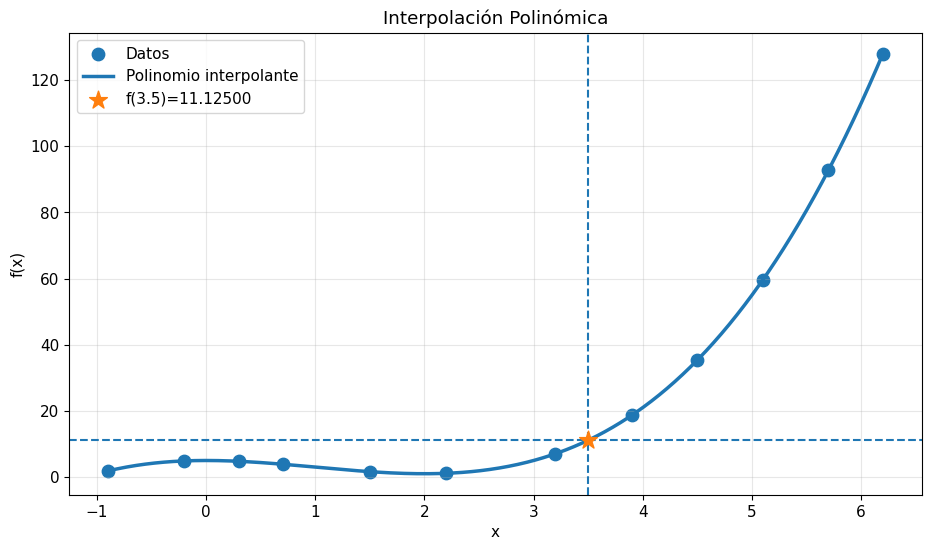

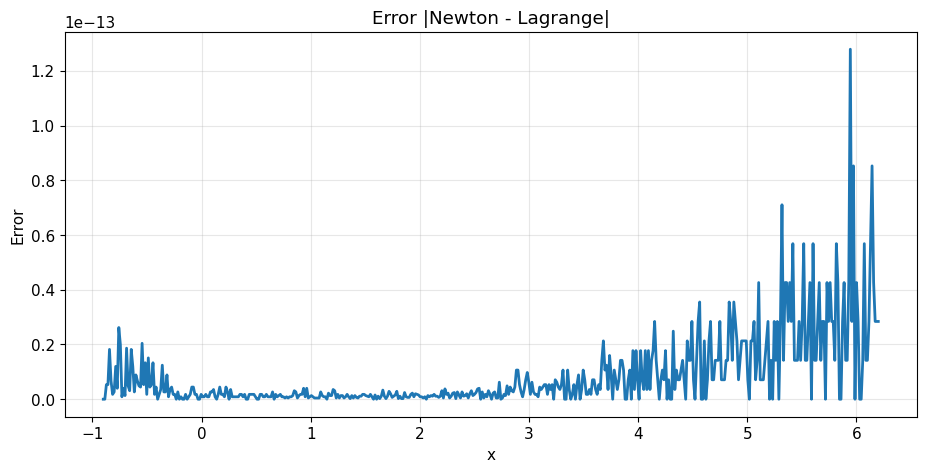

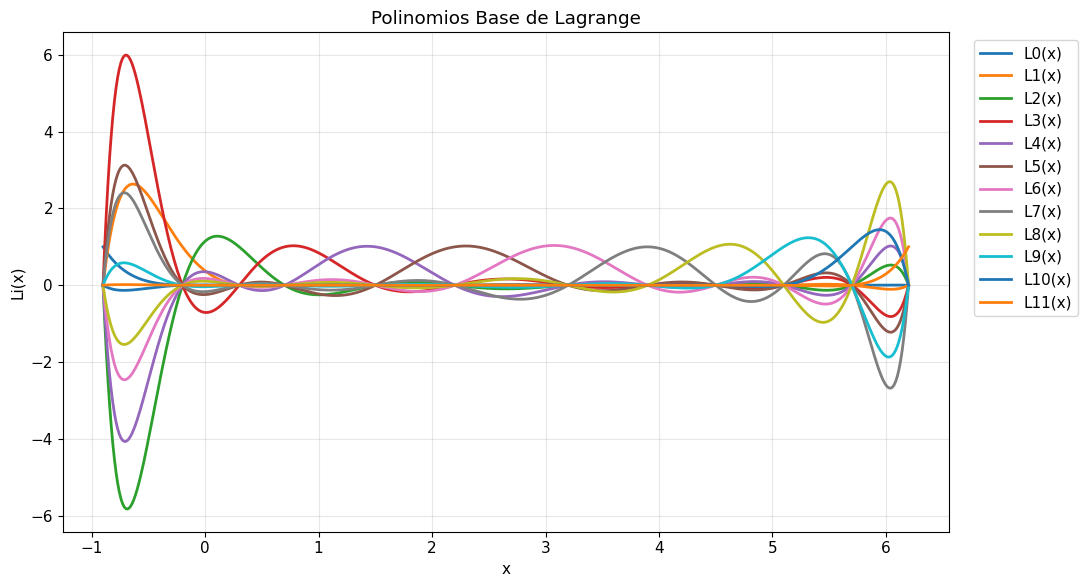



RESUMEN
x evaluado       = 3.5
Newton           = 11.125000000000
Lagrange         = 11.125000000000
Error absoluto   = 1.066e-14
Error relativo % = 9.580e-14


In [9]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from google.colab import files

# =====================================================
# CONFIGURACIÓN GENERAL DE GRÁFICAS
# =====================================================

plt.rcParams['figure.figsize'] = (10,6)
plt.rcParams['font.size'] = 11

# =====================================================
# FUNCIÓN: LIMPIAR LINK
# =====================================================

def limpiar_link(url):

    if "<iframe" in url:
        url = re.search(r'src="([^"]+)"', url).group(1)

    if "pubhtml" in url:
        url = url.split("?")[0]
        url = url.replace("pubhtml", "pub") + "?output=csv"

    elif "pub" in url and "output=csv" not in url:
        url = url.split("?")[0] + "?output=csv"

    return url

# =====================================================
# LIMPIAR DATOS
# =====================================================

def limpiar_datos(data):

    x = (
        data.iloc[:,0]
        .astype(str)
        .str.replace(',', '.')
        .astype(float)
        .values
    )

    y = (
        data.iloc[:,1]
        .astype(str)
        .str.replace(',', '.')
        .astype(float)
        .values
    )

    return x,y


print("\n")
print("="*60)
print("OPCIONES")
print("="*60)


# =====================================================
# CARGA DE DATOS
# =====================================================

modo = input("¿Usar (1) Google Sheets o (2) Excel? ")

if modo == "1":

    url = input("Pega el link de Google Sheets: ")
    url = limpiar_link(url)

    print("\nLink corregido:")
    print(url)

    data = pd.read_csv(url)

elif modo == "2":

    print("\nSube el archivo Excel:")
    uploaded = files.upload()

    archivo = list(uploaded.keys())[0]
    data = pd.read_excel(archivo)

else:

    print("Opción inválida")
    raise SystemExit

print("="*60)
print("DATOS CARGADOS")
print("="*60)
display(data)

# =====================================================
# DATOS
# =====================================================

x,y = limpiar_datos(data)

n = len(x)

# =====================================================
# PUNTO A EVALUAR
# =====================================================

xp = float(input("\nIngrese x a evaluar: "))

# =====================================================
# NEWTON
# =====================================================

D = np.zeros((n,n))
D[:,0] = y

for j in range(1,n):

    for i in range(n-j):

        D[i,j] = (
            D[i+1,j-1]-D[i,j-1]
        )/(x[i+j]-x[i])

p_newton = D[0,0]
producto = 1

for i in range(1,n):

    producto *= (xp-x[i-1])

    p_newton += D[0,i]*producto

# =====================================================
# LAGRANGE
# =====================================================

def lagrange(x,y,xp):

    n = len(x)

    resultado = 0

    for i in range(n):

        Li = 1

        for j in range(n):

            if i != j:

                Li *= (
                    (xp-x[j])/
                    (x[i]-x[j])
                )

        resultado += y[i]*Li

    return resultado

p_lagrange = lagrange(x,y,xp)

# =====================================================
# TABLA DE RESULTADOS
# =====================================================

error_abs = abs(p_newton-p_lagrange)

error_rel = (
    error_abs/abs(p_newton)*100
    if p_newton != 0
    else 0
)

tabla = pd.DataFrame({
    "Método":[
        "Newton",
        "Lagrange"
    ],
    "Resultado":[
        p_newton,
        p_lagrange
    ]
})

print("\n")
print("="*60)
print("RESULTADOS")
print("="*60)

display(
    tabla.style
    .format({"Resultado":"{:.12f}"})
)

print("\n")

tabla_error = pd.DataFrame({
    "Error Absoluto":[error_abs],
    "Error Relativo (%)":[error_rel]
})

display(
    tabla_error.style
    .format({
        "Error Absoluto":"{:.3e}",
        "Error Relativo (%)":"{:.3e}"
    })
)

# =====================================================
# FUNCIÓN EVALUAR NEWTON
# =====================================================

def newton_eval(xp):

    resultado = D[0,0]

    producto = 1

    for i in range(1,n):

        producto *= (xp-x[i-1])

        resultado += D[0,i]*producto

    return resultado

# =====================================================
# CURVA INTERPOLANTE
# =====================================================

xx = np.linspace(min(x),max(x),500)

yy_newton = np.array(
    [newton_eval(v) for v in xx]
)

yy_lagrange = np.array(
    [lagrange(x,y,v) for v in xx]
)

# =====================================================
# GRÁFICA 1
# =====================================================

plt.figure(figsize=(11,6))

plt.scatter(
    x,y,
    s=80,
    label="Datos"
)

plt.plot(
    xx,
    yy_newton,
    linewidth=2.5,
    label="Polinomio interpolante"
)

plt.scatter(
    xp,
    p_newton,
    s=180,
    marker="*",
    zorder=5,
    label=f"f({xp})={p_newton:.5f}"
)

plt.axvline(xp,linestyle="--")
plt.axhline(p_newton,linestyle="--")

plt.title("Interpolación Polinómica")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

# =====================================================
# GRÁFICA 2
# ERROR ENTRE MÉTODOS
# =====================================================

error_curva = np.abs(
    yy_newton-yy_lagrange
)

plt.figure(figsize=(11,5))

plt.plot(
    xx,
    error_curva,
    linewidth=2
)

plt.title("Error |Newton - Lagrange|")
plt.xlabel("x")
plt.ylabel("Error")
plt.grid(alpha=0.3)

plt.show()

# =====================================================
# GRÁFICA 3
# POLINOMIOS BASE DE LAGRANGE
# =====================================================

plt.figure(figsize=(11,6))

for i in range(n):

    Li = []

    for xi in xx:

        valor = 1

        for j in range(n):

            if i != j:

                valor *= (
                    (xi-x[j])/
                    (x[i]-x[j])
                )

        Li.append(valor)

    plt.plot(
        xx,
        Li,
        linewidth=2,
        label=f"L{i}(x)"
    )

plt.title("Polinomios Base de Lagrange")
plt.xlabel("x")
plt.ylabel("Li(x)")
plt.grid(alpha=0.3)
plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# =====================================================
# RESUMEN FINAL
# =====================================================

print("\n")
print("="*60)
print("RESUMEN")
print("="*60)

print(f"x evaluado       = {xp}")
print(f"Newton           = {p_newton:.12f}")
print(f"Lagrange         = {p_lagrange:.12f}")
print(f"Error absoluto   = {error_abs:.3e}")
print(f"Error relativo % = {error_rel:.3e}")